## Plotting aligned parcellation maps across atlases

In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from py_util_dx.data_utils import get_roi_vtx_from_fs32k, get_roi_pacels, get_glasser_labels
from scipy.stats import ttest_1samp
import Functional_Fusion.atlas_map as am 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from visualizations import plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import matplotlib.colors as mcolors

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A3_bayes_parcellation', f'{dataset_name}')

In [4]:
parcellations_of_interests = ['glasser', 'schaefer100']
Vs = []
n_parcels = [] 
roi = 'PFC' 
parcel_names = []

for parcellation in parcellations_of_interests:
    PKL_bayes_parcellation = os.path.join(resultsPath, parcellation, f'output_{roi}.pkl')
    with open(PKL_bayes_parcellation, 'rb') as pf:
        output = pickle.load(pf)
        V = output['V']
        Vs.append(V)
        n_parcels.append(V.shape[1])
        parcel_names.append(output['parcel_names_in_group']) 

In [5]:
Vs = np.hstack(Vs) 

In [6]:
Vs.shape 

(29, 76)

In [7]:
n_parcels

[44, 32]

In [8]:
D = 1 - cosine_similarity(Vs.T)
D.shape 

(76, 76)

In [9]:
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=0,
    n_init=10,
    max_iter=300
)

X_joint = mds.fit_transform(D)  # (76, 2)

In [10]:
X_glasser = X_joint[:n_parcels[0]]
X_schaefer100 = X_joint[n_parcels[0]:] 

In [11]:
def embedding_to_rgb_hsv(X, S_max=0.85, V=0.9):
    x, y = X[:, 0], X[:, 1]

    hue = (np.arctan2(y, x) + np.pi) / (2 * np.pi)
    radius = np.sqrt(x**2 + y**2)

    saturation = np.clip(radius * S_max, 0, S_max)

    hsv = np.column_stack([hue, saturation, np.full(len(X), V)])
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb

In [12]:
color_rgb_glasser = embedding_to_rgb_hsv(X_glasser)
color_rgb_schaefer100 = embedding_to_rgb_hsv(X_schaefer100) 

In [13]:
color_rgb_glasser.shape 

(44, 3)

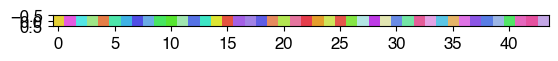

In [14]:
plt.imshow(color_rgb_glasser[np.newaxis, :]) 

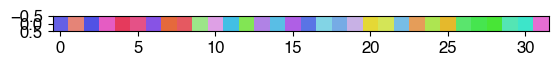

In [15]:
plt.imshow(color_rgb_schaefer100[np.newaxis, :]) 

In [16]:
color_df_glasser = pd.DataFrame(data=color_rgb_glasser, index=parcel_names[0], columns=['r', 'g', 'b']) 
color_df_glasser

,r,g,b
55b,0.900000,0.819708,0.213642
SFL,0.900000,0.360512,0.882091
a24,0.329098,0.900000,0.899387
d32,0.621672,0.900000,0.529572
8BM,0.900000,0.490636,0.280585
p32,0.303919,0.900000,0.666892
10r,0.248721,0.700721,0.900000
47m,0.315719,0.308028,0.900000
8Av,0.418452,0.675707,0.900000
8Ad,0.280263,0.900000,0.383490


In [17]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', header=None)  
temp_df = temp_df.rename(columns={0:'indx', 1:'r', 2:'g', 3:'b', 4:'roi'})
temp_df

,indx,r,g,b,roi
0,1,0.0,0.200000,0.4,L_V1_ROI
1,2,0.2118,0.403900,0.5059,L_MST_ROI
2,3,0.2431,0.305900,0.698,L_V6_ROI
3,4,0.0,0.298000,0.6,L_V2_ROI
4,5,0.0,0.400000,0.8,L_V3_ROI
...,...,...,...,...,...
355,176,0.1922,0.156900,0.1373,R_STSva_ROI
356,177,0.3216,0.211800,0.2314,R_TE1m_ROI
357,178,0.5059,0.231400,0.2431,R_PI_ROI
358,179,0.9,0.319916,0.6269620621715519,R_a32pr_ROI


In [18]:
temp_df.index = temp_df['roi'].str.lstrip('LR_').str.rstrip('_ROI') 
temp_df

,indx,r,g,b,roi
roi,,,,,
V1,1,0.0,0.200000,0.4,L_V1_ROI
MST,2,0.2118,0.403900,0.5059,L_MST_ROI
V6,3,0.2431,0.305900,0.698,L_V6_ROI
V2,4,0.0,0.298000,0.6,L_V2_ROI
V3,5,0.0,0.400000,0.8,L_V3_ROI
...,...,...,...,...,...
STSva,176,0.1922,0.156900,0.1373,R_STSva_ROI
TE1m,177,0.3216,0.211800,0.2314,R_TE1m_ROI
P,178,0.5059,0.231400,0.2431,R_PI_ROI


In [19]:
temp_df.update(color_df_glasser)
temp_df

,indx,r,g,b,roi
roi,,,,,
V1,1,0.0,0.200000,0.4,L_V1_ROI
MST,2,0.2118,0.403900,0.5059,L_MST_ROI
V6,3,0.2431,0.305900,0.698,L_V6_ROI
V2,4,0.0,0.298000,0.6,L_V2_ROI
V3,5,0.0,0.400000,0.8,L_V3_ROI
...,...,...,...,...,...
STSva,176,0.1922,0.156900,0.1373,R_STSva_ROI
TE1m,177,0.3216,0.211800,0.2314,R_TE1m_ROI
P,178,0.5059,0.231400,0.2431,R_PI_ROI


In [20]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', index=False, header=False)

In [21]:
# names = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 1)  
# names = names.rename(columns={0:'roi'})
# names 

In [22]:
# colors = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 0, sep=' ')
# colors

In [23]:
# temp_df = pd.merge(colors[[0, 1, 2, 3]], names, left_index=True, right_index=True) 
# temp_df

In [24]:
# temp_df = temp_df.rename(columns={0: 'indx', 1: 'r', 2: 'g', 3: 'b'}) 
# temp_df

In [25]:
# temp_df[['r', 'g', 'b']] /= 255 
# temp_df 

In [26]:
# temp_df = temp_df.set_index('indx') 
# temp_df

In [27]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep='\s+', header=None, names=['indx', 'r', 'g', 'b', 'roi'])
temp_df 

,indx,r,g,b,roi
0,1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
1,2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
2,3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
3,4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
4,5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
...,...,...,...,...,...
95,96,0.019608,0.000000,0.513725,17Networks_RH_DefaultC_Rsp_1
96,97,0.019608,0.000000,0.517647,17Networks_RH_DefaultC_PHC_1
97,98,0.062745,0.188235,1.000000,17Networks_RH_TempPar_1
98,99,0.050980,0.160784,0.980392,17Networks_RH_TempPar_2


In [28]:
temp_df = temp_df.set_index('indx') 
temp_df 

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
...,...,...,...,...
96,0.019608,0.000000,0.513725,17Networks_RH_DefaultC_Rsp_1
97,0.019608,0.000000,0.517647,17Networks_RH_DefaultC_PHC_1
98,0.062745,0.188235,1.000000,17Networks_RH_TempPar_1


In [29]:
temp_df[0:20]

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
6,1.000000,0.000000,0.011765,17Networks_LH_VisPeri_StriCal_1
7,1.000000,0.000000,0.015686,17Networks_LH_VisPeri_ExStrSup_1
8,0.274510,0.509804,0.709804,17Networks_LH_SomMotA_1
9,0.274510,0.509804,0.713725,17Networks_LH_SomMotA_2


In [30]:
color_df_schaefer100 = pd.DataFrame(data=color_rgb_schaefer100, index=list(map(int, parcel_names[1])), columns=['r', 'g', 'b']) 
color_df_schaefer100.index.name = 'indx' 
color_df_schaefer100

,r,g,b
indx,,,
13,0.398554,0.378979,0.900000
20,0.900000,0.520775,0.466781
23,0.320479,0.322830,0.900000
25,0.900000,0.364017,0.766520
26,0.900000,0.228209,0.363890
27,0.900000,0.317970,0.531019
28,0.530652,0.328603,0.900000
32,0.900000,0.414542,0.236258
33,0.900000,0.350780,0.381066


In [31]:
temp_df.update(color_df_schaefer100)
temp_df[0:20]

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
6,1.000000,0.000000,0.011765,17Networks_LH_VisPeri_StriCal_1
7,1.000000,0.000000,0.015686,17Networks_LH_VisPeri_ExStrSup_1
8,0.274510,0.509804,0.709804,17Networks_LH_SomMotA_1
9,0.274510,0.509804,0.713725,17Networks_LH_SomMotA_2


In [32]:
color_df_schaefer100.index 

Index([13, 20, 23, 25, 26, 27, 28, 32, 33, 34, 38, 40, 44, 45, 46, 47, 57, 64,
       72, 74, 76, 77, 78, 81, 82, 85, 86, 90, 92, 93, 94, 95],
      dtype='int64', name='indx')

In [33]:
temp_df.index 

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
        85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100],
      dtype='int64', name='indx')

In [34]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep=' ', index=True, header=False) 

In [35]:
# getting the mds solutions for individuals 
Vs_indv = [] 

for parcellation in parcellations_of_interests:
    PKL_Vs = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', dataset_name, parcellation, f'output_{roi}_cv.pkl')
    with open(PKL_Vs, 'rb') as pf:
        output_indv = pickle.load(pf)
        Vs_indv.append(output_indv['Vs'])

Vs_indv = np.concatenate(Vs_indv, axis=-1) 
Vs_indv.shape 

(24, 32, 76)

In [36]:
n_subjects = Vs_indv.shape[0]

In [37]:
Vs_indv = np.hstack(Vs_indv) 
Vs_indv.shape 

(32, 1824)

In [38]:
Ds = 1 - cosine_similarity(Vs_indv.T) 
Ds.shape 

(1824, 1824)

In [39]:
X_indiv = mds.fit_transform(Ds)
X_indiv.shape 

(1824, 2)

In [40]:
X_indiv = X_indiv.reshape((n_subjects, -1, 2))
X_indiv.shape 

(24, 76, 2)

In [41]:
X_indiv_glasser = X_indiv[:, :n_parcels[0]]
X_indiv_schaefer100 = X_indiv[:, n_parcels[0]:] 
X_indiv_glasser.shape 

(24, 44, 2)

In [42]:
color_rgb_glasser_indiv = [embedding_to_rgb_hsv(y) for y in X_indiv_glasser] 
color_rgb_schaefer100_indiv = [embedding_to_rgb_hsv(y) for y in X_indiv_schaefer100] 

In [43]:
# generating color for each subject for the individualized glass atlas
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', header=None)  
temp_df = temp_df.rename(columns={0:'indx', 1:'r', 2:'g', 3:'b', 4:'roi'})
temp_df.index = temp_df['roi'].str.lstrip('LR_').str.rstrip('_ROI') 
temp_df

,indx,r,g,b,roi
roi,,,,,
V1,1,0.0,0.200000,0.4,L_V1_ROI
MST,2,0.2118,0.403900,0.5059,L_MST_ROI
V6,3,0.2431,0.305900,0.698,L_V6_ROI
V2,4,0.0,0.298000,0.6,L_V2_ROI
V3,5,0.0,0.400000,0.8,L_V3_ROI
...,...,...,...,...,...
STSva,176,0.1922,0.156900,0.1373,R_STSva_ROI
TE1m,177,0.3216,0.211800,0.2314,R_TE1m_ROI
P,178,0.5059,0.231400,0.2431,R_PI_ROI


In [44]:
for subjI in np.arange(n_subjects):
    color_df = pd.DataFrame(data=color_rgb_glasser_indiv[subjI], index=parcel_names[0], columns=['r', 'g', 'b']) 
    temp_df.update(color_df)
    temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-glasser-aligned_subj{subjI}.lut'), sep=' ', index=False, header=False) 

In [45]:
# generating color for each subject for the individualized schaefer100 atlas
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep='\s+', header=None, names=['indx', 'r', 'g', 'b', 'roi'])
temp_df = temp_df.set_index('indx') 
temp_df 

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
...,...,...,...,...
96,0.019608,0.000000,0.513725,17Networks_RH_DefaultC_Rsp_1
97,0.019608,0.000000,0.517647,17Networks_RH_DefaultC_PHC_1
98,0.062745,0.188235,1.000000,17Networks_RH_TempPar_1


In [46]:
for subjI in np.arange(n_subjects):
    color_df = pd.DataFrame(data=color_rgb_schaefer100_indiv[subjI], index=list(map(int, parcel_names[1])), columns=['r', 'g', 'b']) 
    color_df.index.name = 'indx' 
    temp_df.update(color_df)
    temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100-aligned_subj{subjI}.lut'), sep=' ', index=True, header=False) 

In [53]:
# atlas_name = 'glasser'
atlas_name = 'schaefer100'
# atlas_name = 'yeo17'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}', atlas_name, 'hyper_aligned_atlas')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [54]:
example_subjIs = np.arange(n_subjects)
n_example_subjects = len(example_subjIs) 
frames_dict = {
    'PFC': [[-210, 25, -90, 140], [0, 240, -110, 120]], 
    'visual': [[100, 230, -70, 160], [-250, -50, -70, 130]], 
    'somatosensory':[[-10, 80, -10, 160], [-60, 30, -10, 140]], 
    'parietal': [[20, 140, 0, 160], [-140, -30, 0, 160]]
}
gridspec_dict = {
    'PFC': [-0.2, -0.05],
    'visual': [-0.2, -0.12],
    'parietal': [-0.55, -0.25],
    'somatosensory': [-0.55, -0.05]
}

In [55]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [56]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_{roi}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    labels_in_group = output_indiv['labels_in_group']
    parcel_names_in_group = output_indiv['parcel_names_in_group']

    U_individual = output_indiv['U_individual']     # data only parcellation
    indiv_parcellation = output_indiv['indiv_parcellation']

    U_group = output_indiv['U_group']
    group_parcellation = output_indiv['group_parcellation']

    group_parcellation[group_parcellation==0] = np.max(group_parcellation)

/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_11811/3286849664.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_11811/3286849664.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


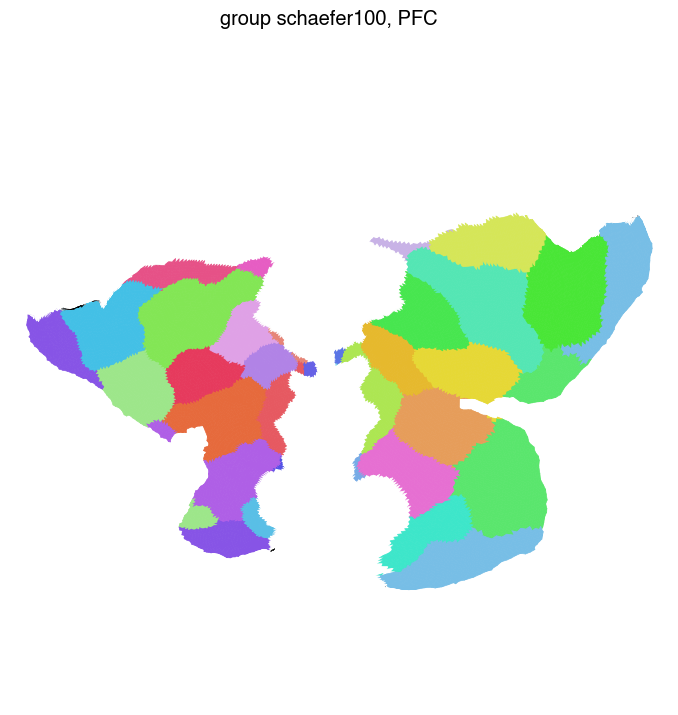

In [57]:
# plotting the group map
fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
fig.set_figwidth(full_width)

[label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
plt.axes(ax[0])
plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name)

plt.axes(ax[1])
plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name)

plt.suptitle(f'group {atlas_name}, {roi}')
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'group_{atlas_name}_{roi}.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_11811/3396828388.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_11811/3396828388.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarn

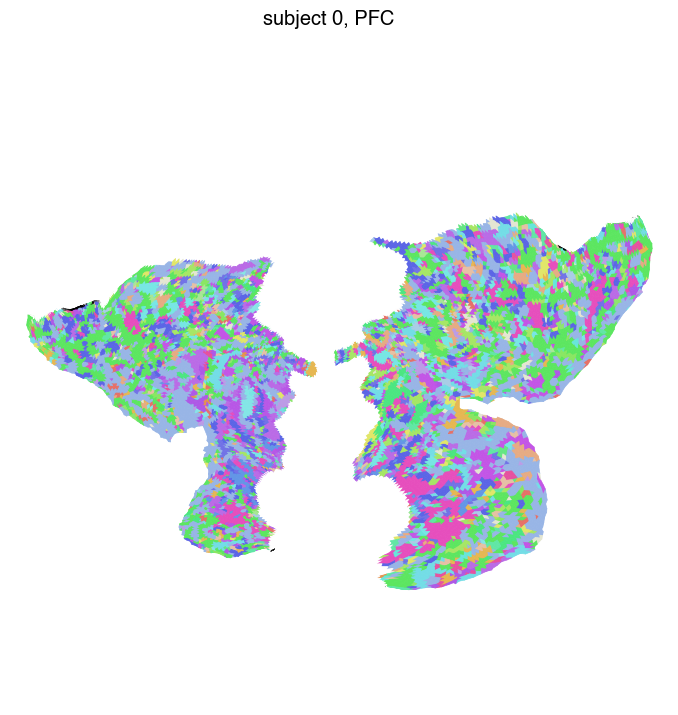

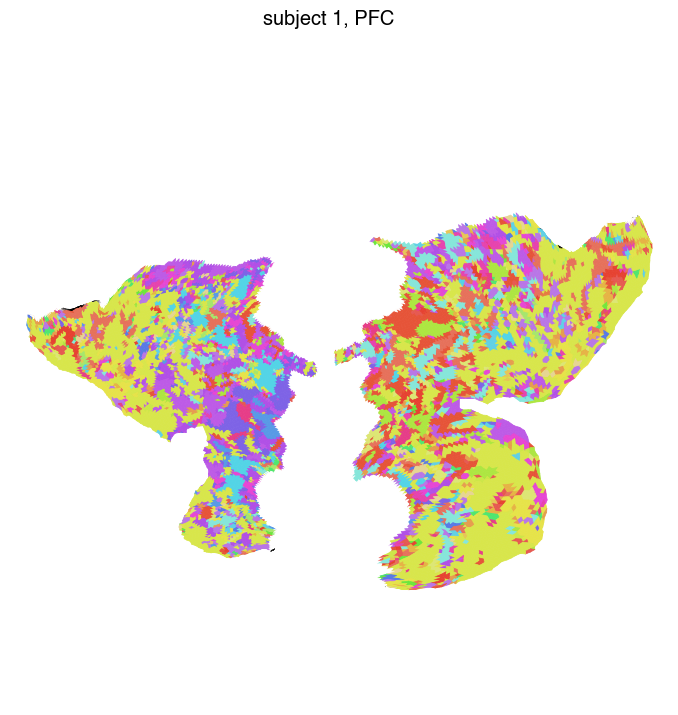

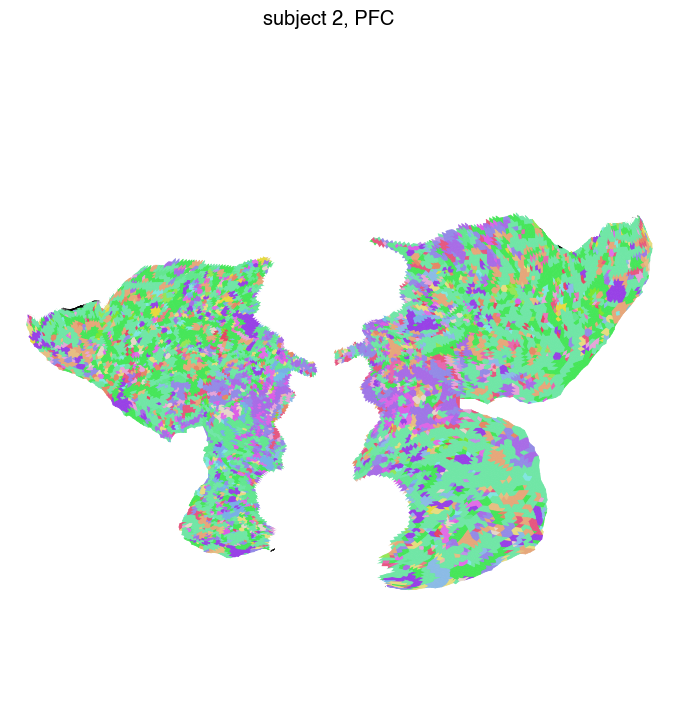

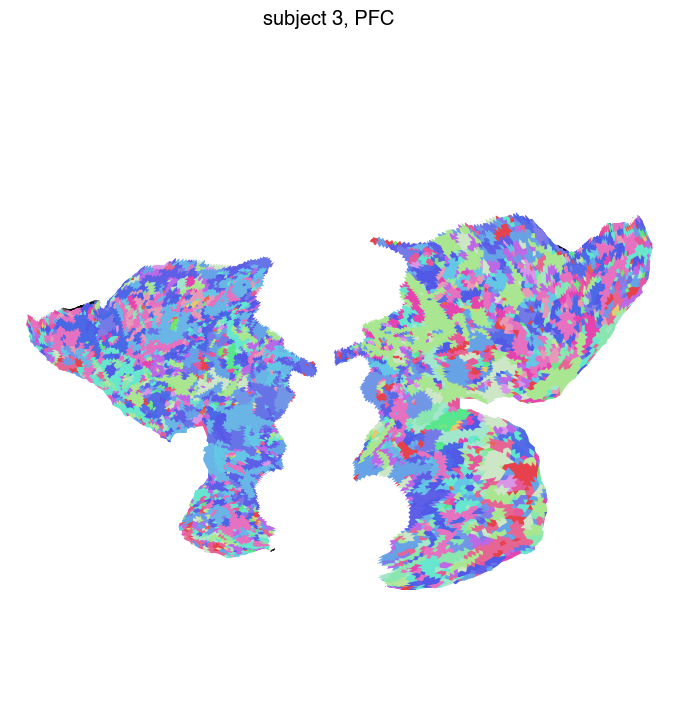

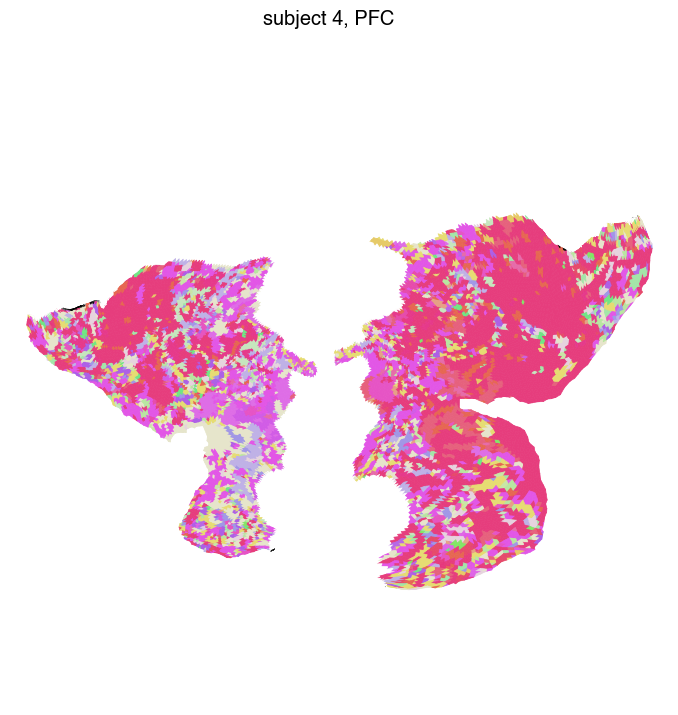

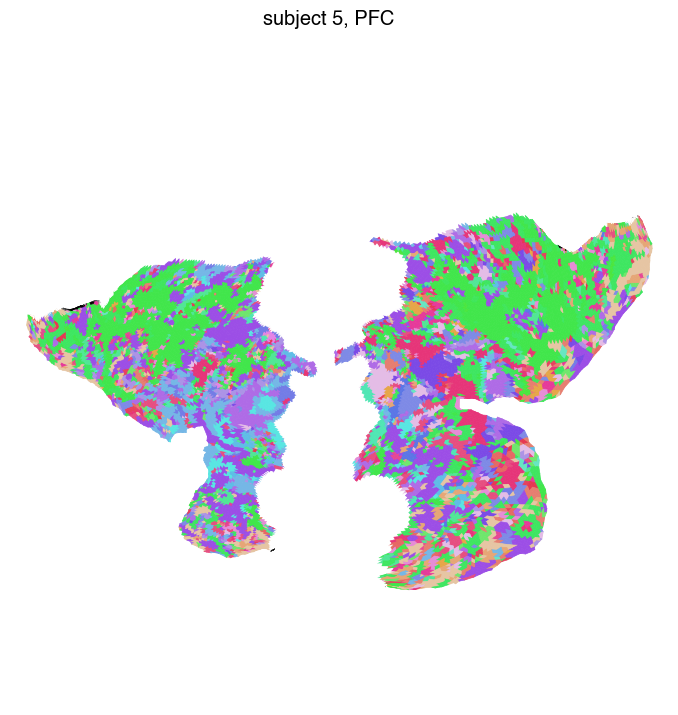

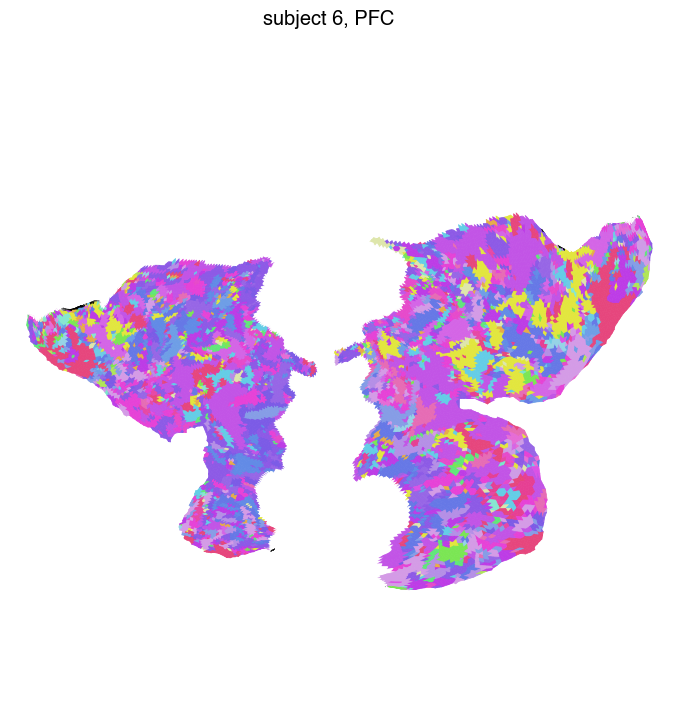

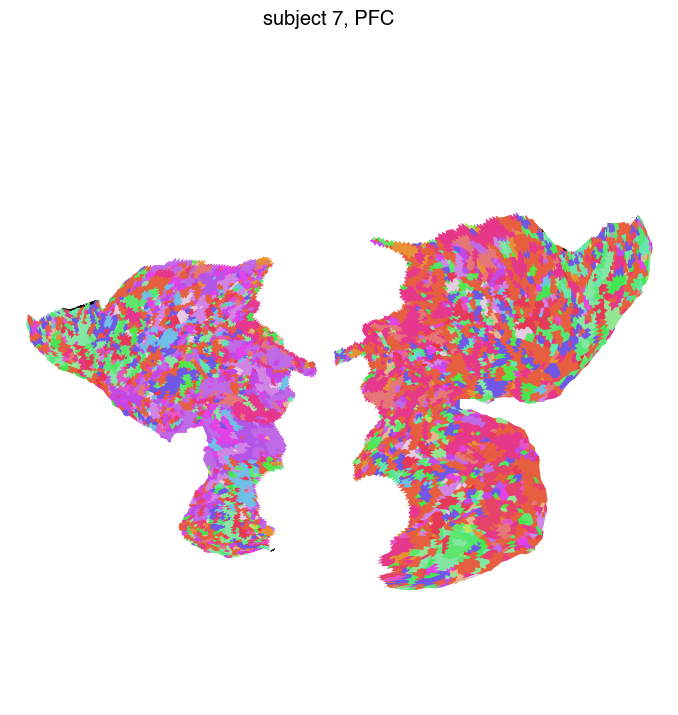

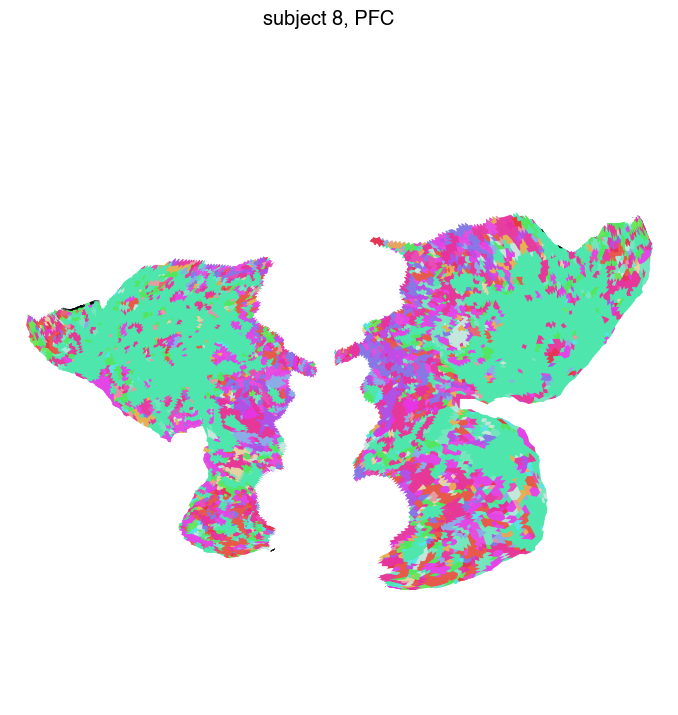

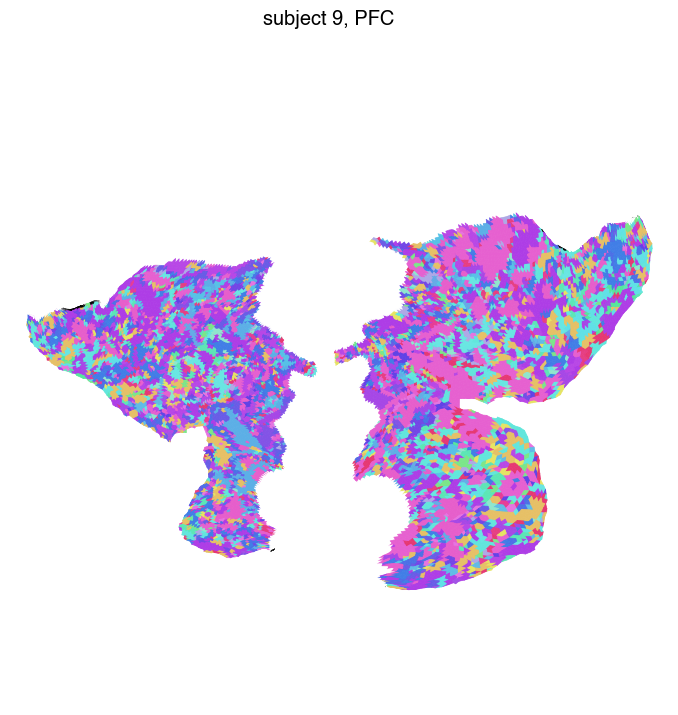

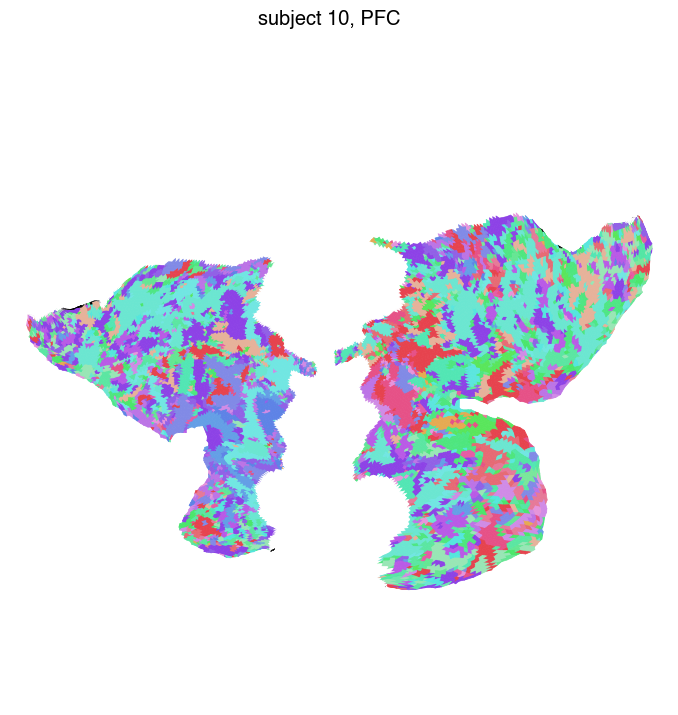

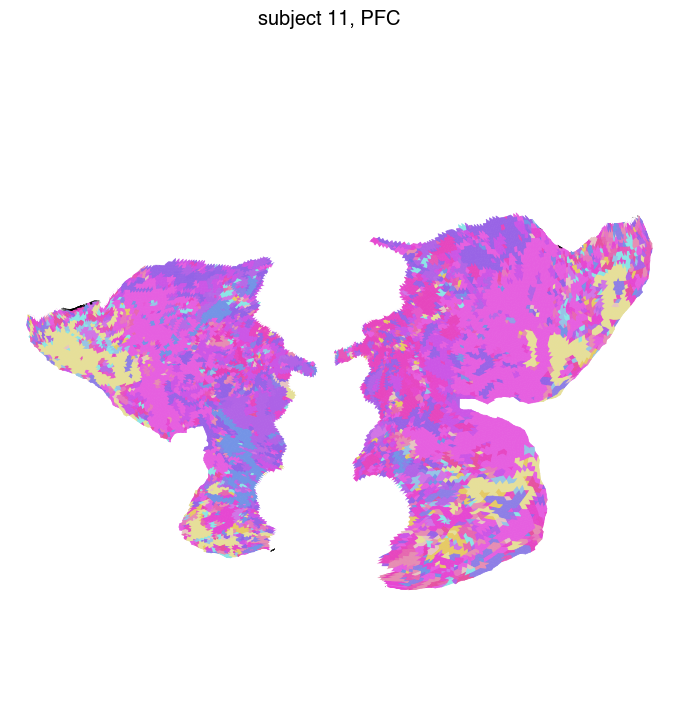

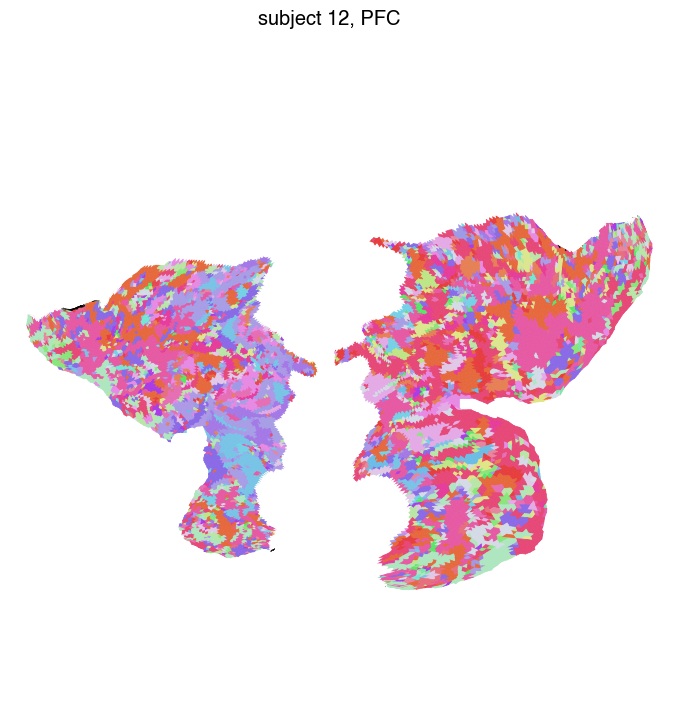

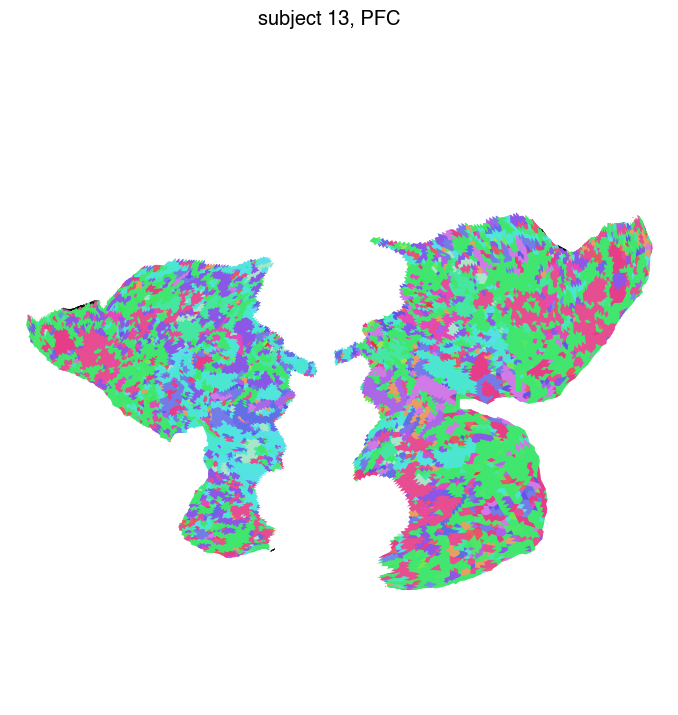

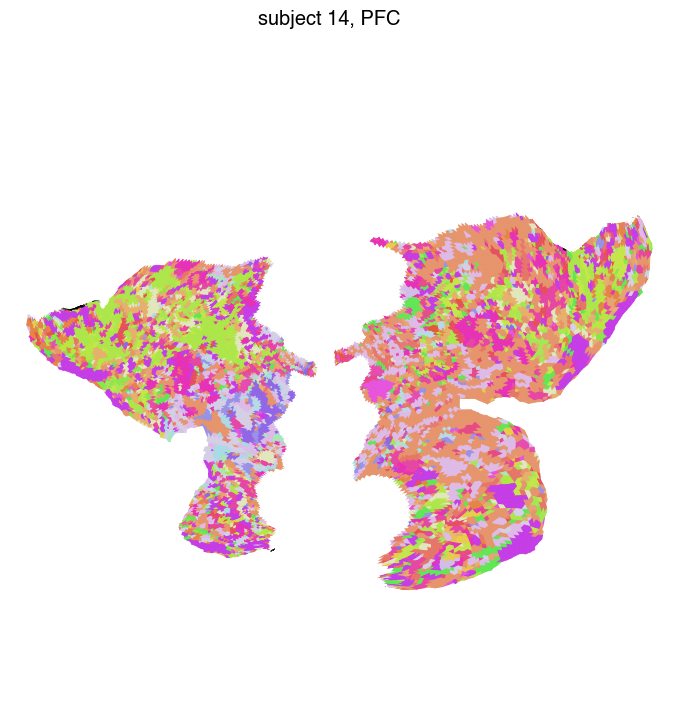

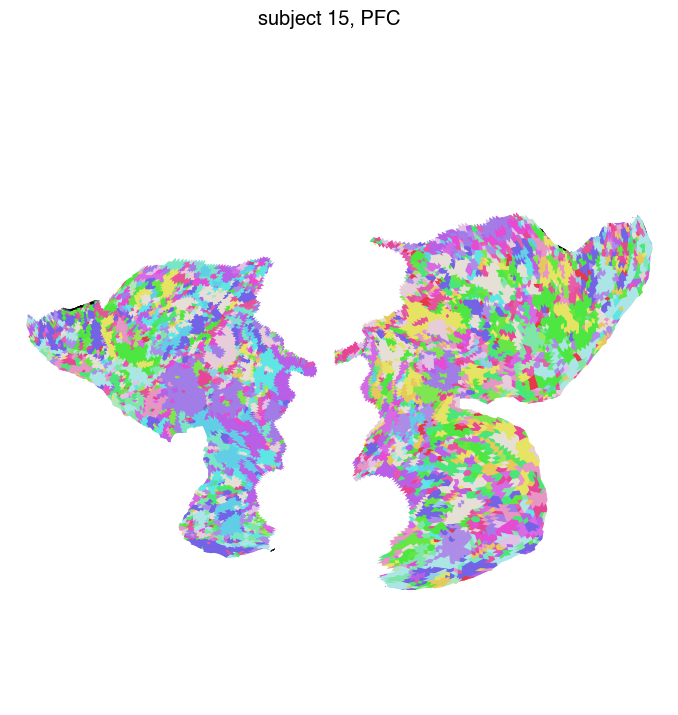

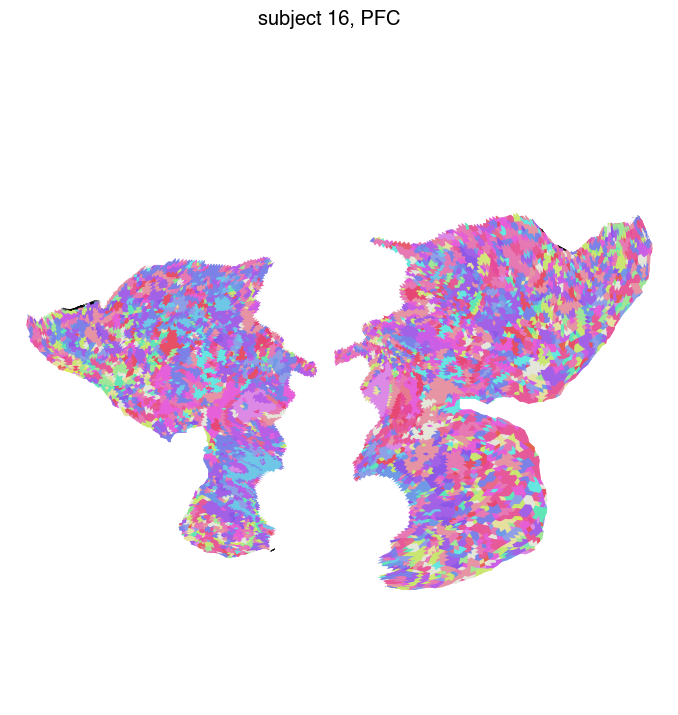

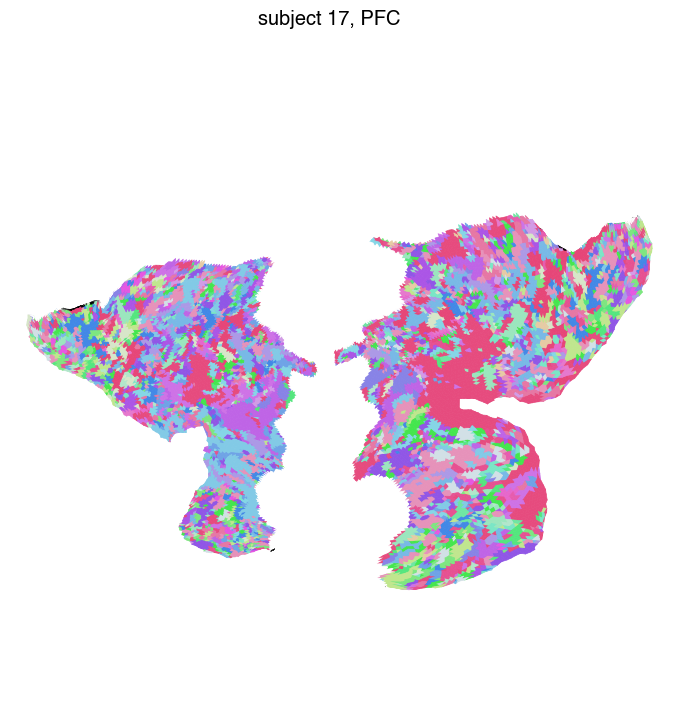

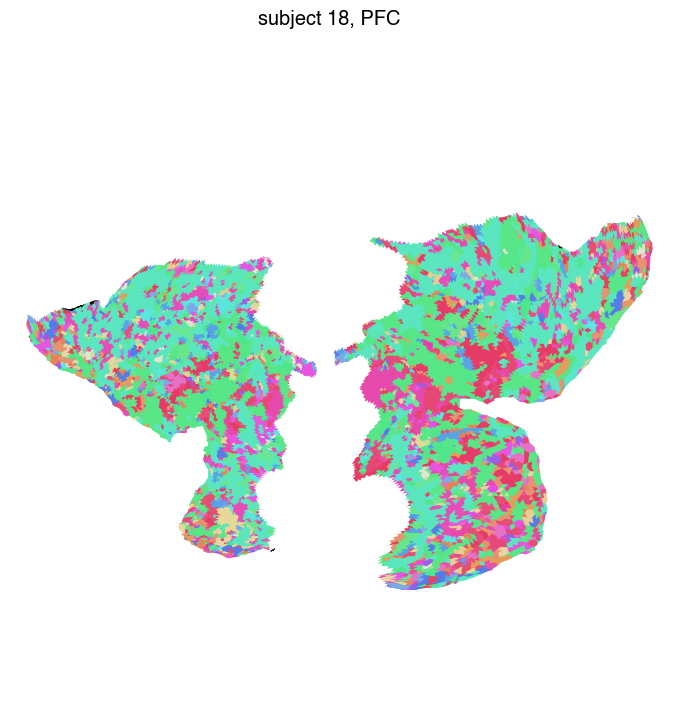

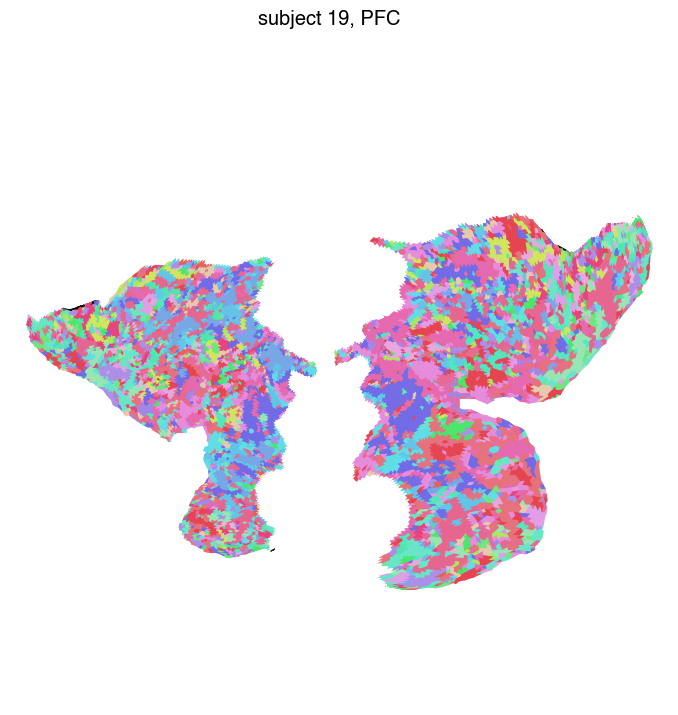

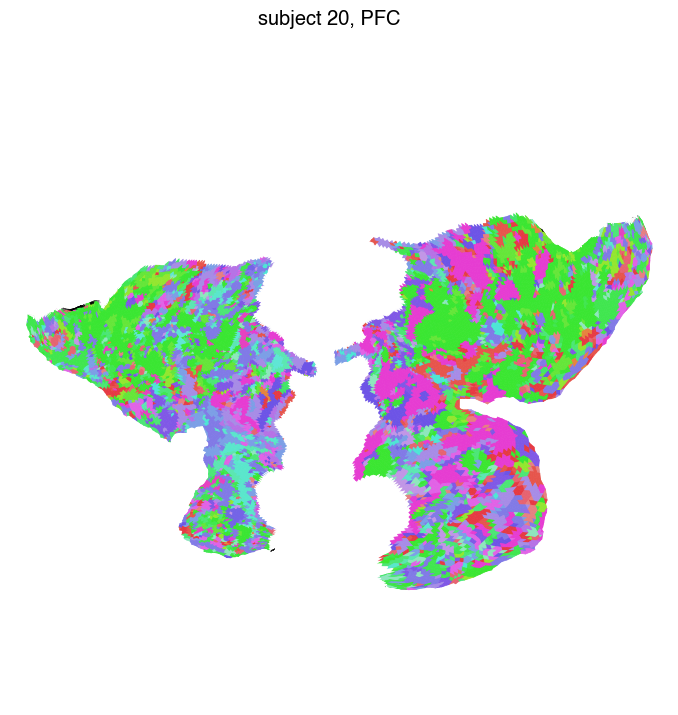

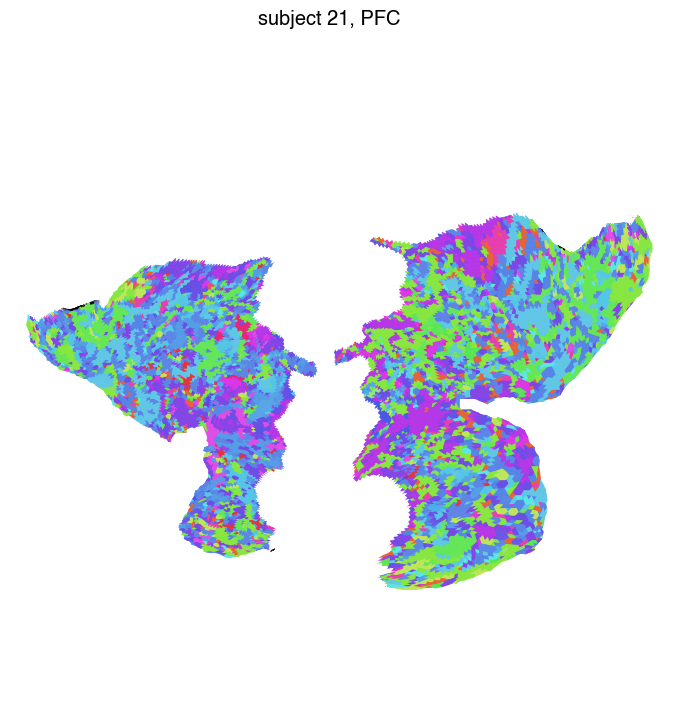

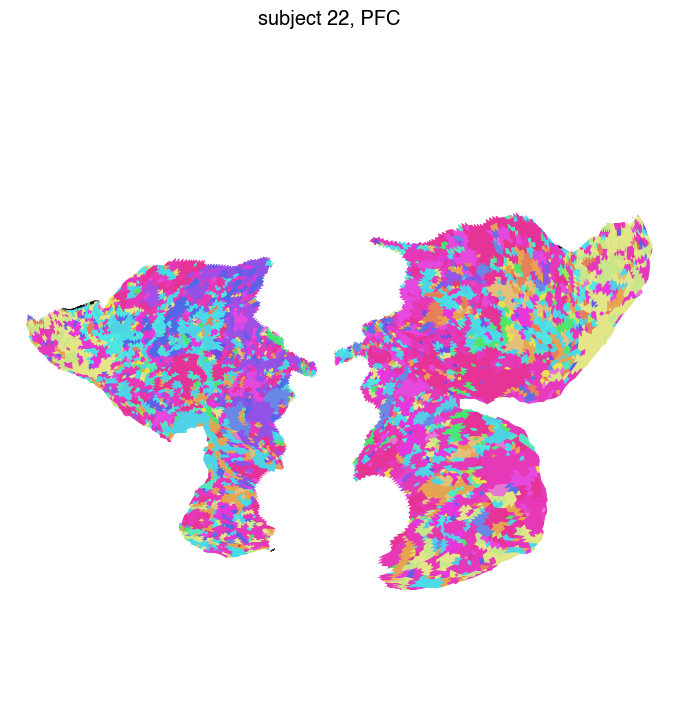

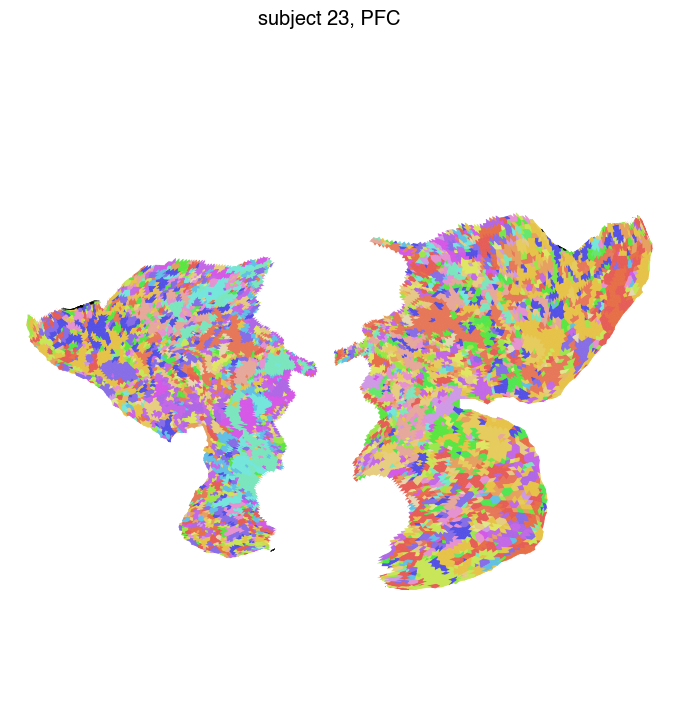

In [58]:
for subjI in example_subjIs:
    fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
    fig.set_figwidth(full_width)
    
    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[subjI].reshape(1, -1)))
    plt.axes(ax[0])
    plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name, lut=os.path.join(surface_helpers_dir, f'atl-{atlas_name}-aligned_subj{subjI}.lut'))
    
    plt.axes(ax[1])
    plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name, lut=os.path.join(surface_helpers_dir, f'atl-{atlas_name}-aligned_subj{subjI}.lut'))

    plt.suptitle(f'subject {subjI}, {roi}')
    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'example_{atlas_name}_{roi}_subject_{subjI}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')